<a href="https://colab.research.google.com/github/AyeshaThapa/Projects/blob/main/OCD_patients.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Importing Libaries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


Loading datasets

In [ ]:
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/ocd_patients_dataset.csv')
df.head()


,Patient ID,Age,Gender,Ethnicity,Marital Status,Education Level,OCD Diagnosis Date,Duration of Symptoms (months),Previous Diagnoses,Family History of OCD,Obsession Type,Compulsion Type,Y-BOCS Score (Obsessions),Y-BOCS Score (Compulsions),Depression Diagnosis,Anxiety Diagnosis,Medications
0,1018,32,Female,African,Single,Some College,2016-07-15,203,MDD,No,Harm-related,Checking,17,10,Yes,Yes,SNRI
1,2406,69,Male,African,Divorced,Some College,2017-04-28,180,NaN,Yes,Harm-related,Washing,21,25,Yes,Yes,SSRI
2,1188,57,Male,Hispanic,Divorced,College Degree,2018-02-02,173,MDD,No,Contamination,Checking,3,4,No,No,Benzodiazepine
3,6200,27,Female,Hispanic,Married,College Degree,2014-08-25,126,PTSD,Yes,Symmetry,Washing,14,28,Yes,Yes,SSRI
4,5824,56,Female,Hispanic,Married,High School,2022-02-20,168,PTSD,Yes,Hoarding,Ordering,39,18,No,No,NaN


In [ ]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/1JEXcMK9p1jhF2ZNDs-EXwWjPXTxKaKHeFGAxPbIUw9M/edit#gid=0


Basic Data exploration

In [ ]:
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Patient ID                     1500 non-null   int64 
 1   Age                            1500 non-null   int64 
 2   Gender                         1500 non-null   object
 3   Ethnicity                      1500 non-null   object
 4   Marital Status                 1500 non-null   object
 5   Education Level                1500 non-null   object
 6   OCD Diagnosis Date             1500 non-null   object
 7   Duration of Symptoms (months)  1500 non-null   int64 
 8   Previous Diagnoses             1252 non-null   object
 9   Family History of OCD          1500 non-null   object
 10  Obsession Type                 1500 non-null   object
 11  Compulsion Type                1500 non-null   object
 12  Y-BOCS Score (Obsessions)      1500 non-null   int64 
 13  Y-B

,0
Patient ID,0
Age,0
Gender,0
Ethnicity,0
Marital Status,0
Education Level,0
OCD Diagnosis Date,0
Duration of Symptoms (months),0
Previous Diagnoses,248
Family History of OCD,0


Handing the missing values

In [ ]:

df['Previous Diagnoses'] = df['Previous Diagnoses'].fillna('None')
df['Medications'] = df['Medications'].fillna('Unknown')


Demographic data Visualization

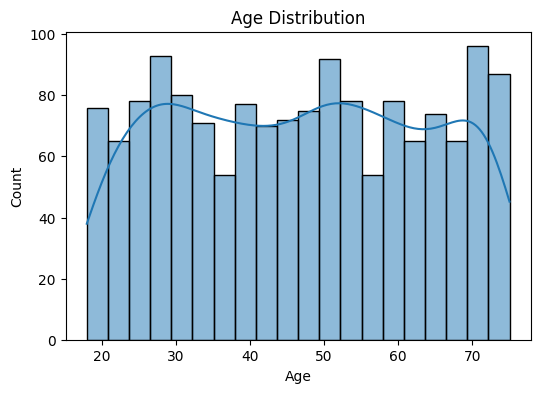

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(df['Age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()


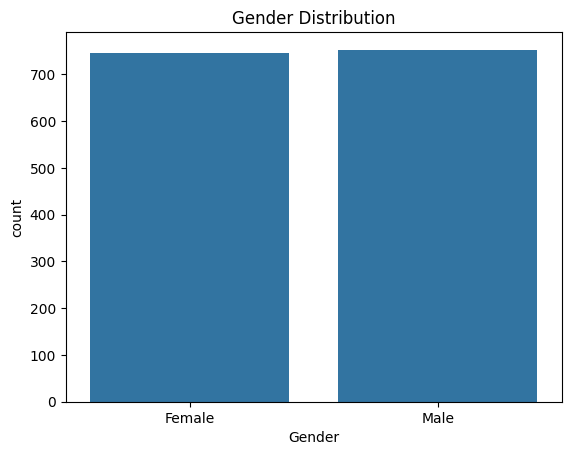

In [ ]:
sns.countplot(x='Gender', data=df)
plt.title("Gender Distribution")
plt.show()


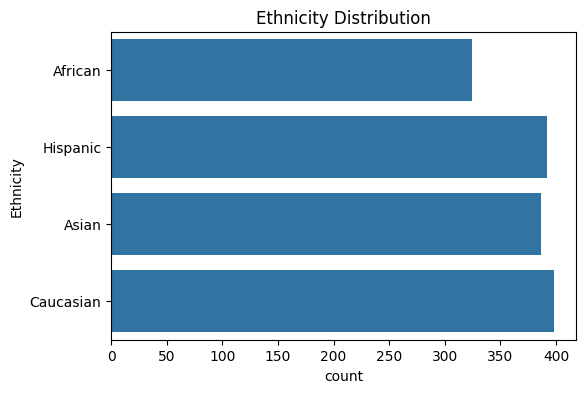

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(y='Ethnicity', data=df)
plt.title("Ethnicity Distribution")
plt.show()


Clinical Data Visualization

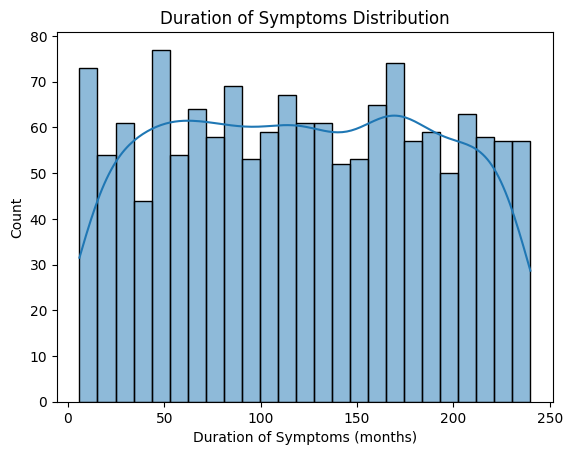

In [ ]:
sns.histplot(df['Duration of Symptoms (months)'], bins=25, kde=True)
plt.title("Duration of Symptoms Distribution")
plt.show()


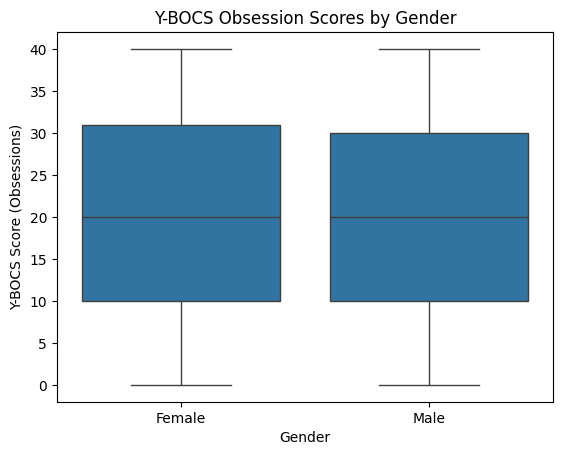

In [ ]:
sns.boxplot(x='Gender', y='Y-BOCS Score (Obsessions)', data=df)
plt.title("Y-BOCS Obsession Scores by Gender")
plt.show()


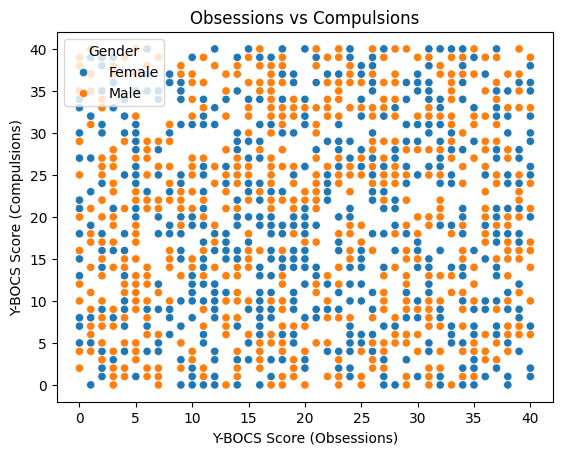

In [ ]:
sns.scatterplot(
    x='Y-BOCS Score (Obsessions)',
    y='Y-BOCS Score (Compulsions)',
    hue='Gender',
    data=df
)
plt.title("Obsessions vs Compulsions")
plt.show()


Encoding Categorical features

In [ ]:
label_cols = [
    'Gender','Ethnicity','Marital Status','Education Level',
    'Previous Diagnoses','Family History of OCD',
    'Obsession Type','Compulsion Type',
    'Depression Diagnosis','Anxiety Diagnosis','Medications'
]

encoder = LabelEncoder()
for col in label_cols:
    df[col] = encoder.fit_transform(df[col])


Correlation Analysis

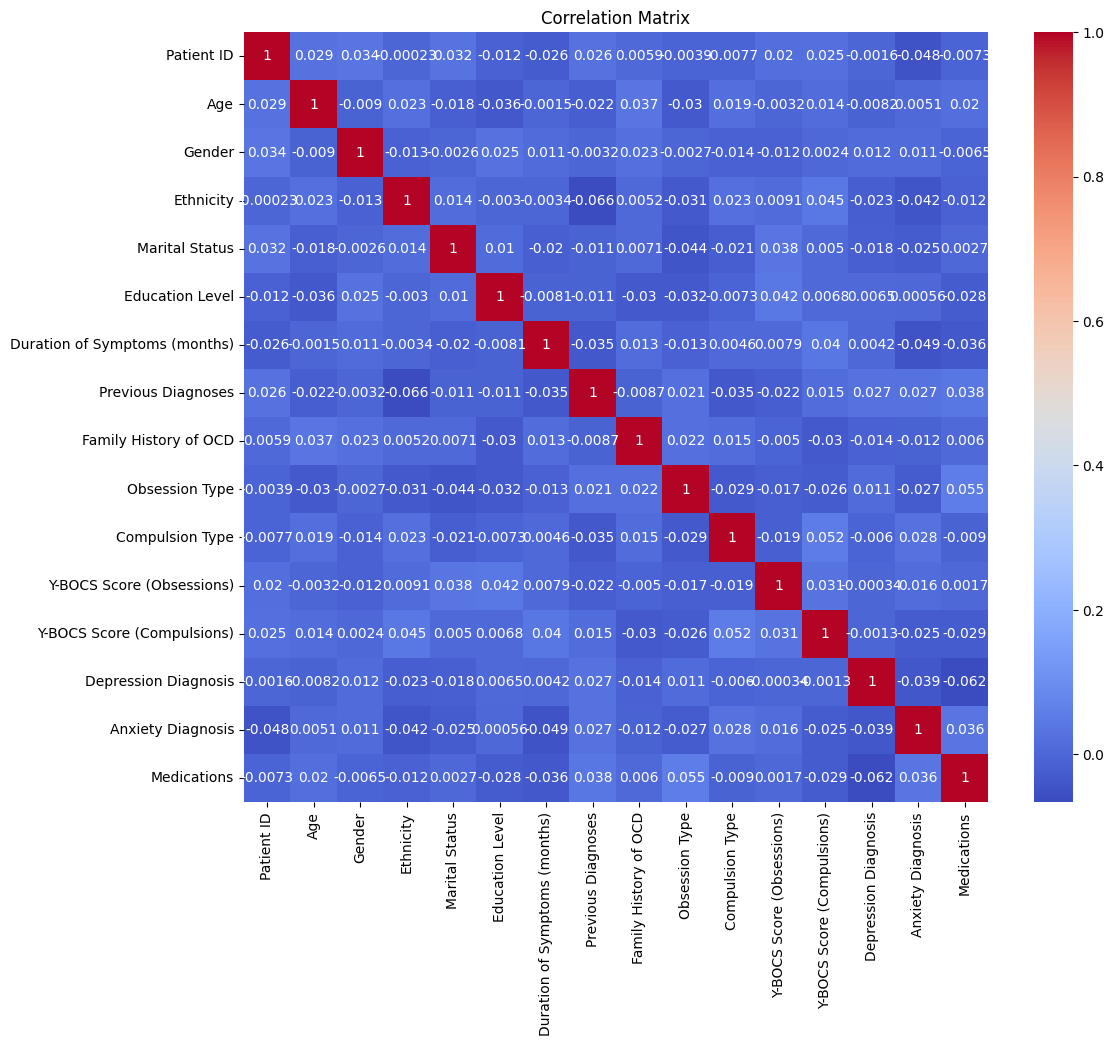

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(df.drop('OCD Diagnosis Date', axis=1).corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Feature Selection

In [ ]:
X = df.drop(['Patient ID','Medications','OCD Diagnosis Date'], axis=1)
y = df['Medications']


Feature Scaling

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


Train-Test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)


Age Group vs OCD Severity (Bar Plot)

/tmp/ipython-input-1228721285.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_severity = df.groupby('Age Group')['Y-BOCS Score (Obsessions)'].mean()


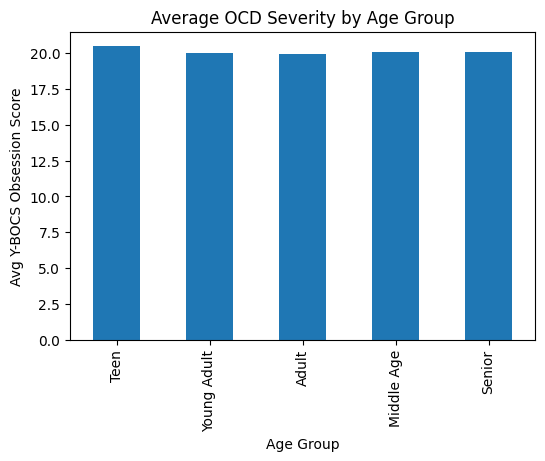

In [ ]:
df['Age Group'] = pd.cut(
    df['Age'],
    bins=[0,18,30,45,60,80],
    labels=['Teen','Young Adult','Adult','Middle Age','Senior']
)

age_severity = df.groupby('Age Group')['Y-BOCS Score (Obsessions)'].mean()

age_severity.plot(kind='bar', figsize=(6,4))
plt.title("Average OCD Severity by Age Group")
plt.ylabel("Avg Y-BOCS Obsession Score")
plt.xlabel("Age Group")
plt.show()


Gender vs Depression Diagnosis (Stacked Bar)

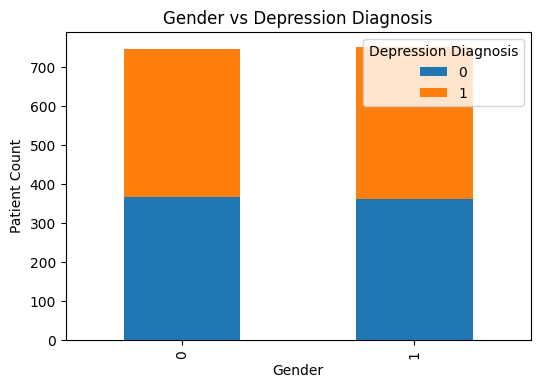

In [ ]:
gender_depression = pd.crosstab(df['Gender'], df['Depression Diagnosis'])
gender_depression.plot(kind='bar', stacked=True, figsize=(6,4))
plt.title("Gender vs Depression Diagnosis")
plt.ylabel("Patient Count")
plt.xlabel("Gender")
plt.show()


Family History vs OCD Severity (Bar Plot)

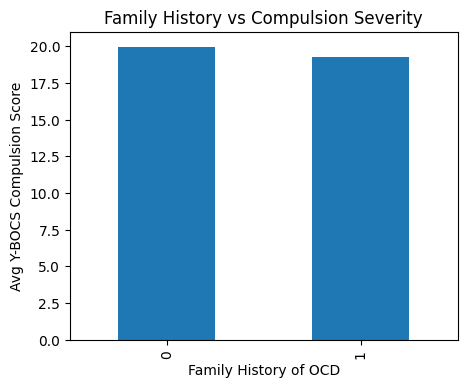

In [ ]:
family_severity = df.groupby('Family History of OCD')['Y-BOCS Score (Compulsions)'].mean()

family_severity.plot(kind='bar', figsize=(5,4))
plt.title("Family History vs Compulsion Severity")
plt.ylabel("Avg Y-BOCS Compulsion Score")
plt.xlabel("Family History of OCD")
plt.show()


Education Level vs Duration of Symptoms

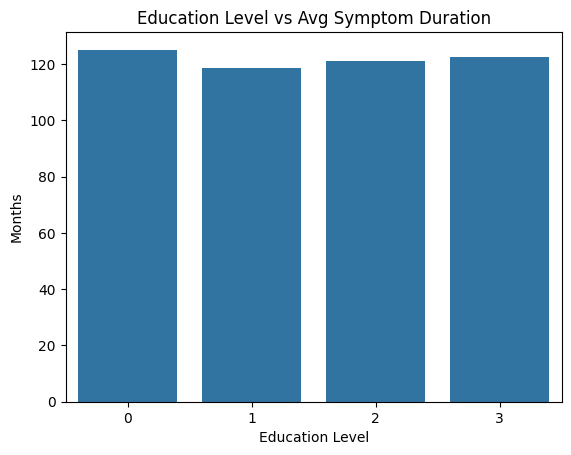

In [ ]:
edu_duration = df.groupby('Education Level')['Duration of Symptoms (months)'].mean()

sns.barplot(
    x=edu_duration.index,
    y=edu_duration.values
)
plt.title("Education Level vs Avg Symptom Duration")
plt.ylabel("Months")
plt.xlabel("Education Level")
plt.show()


Obsession Type Distribution

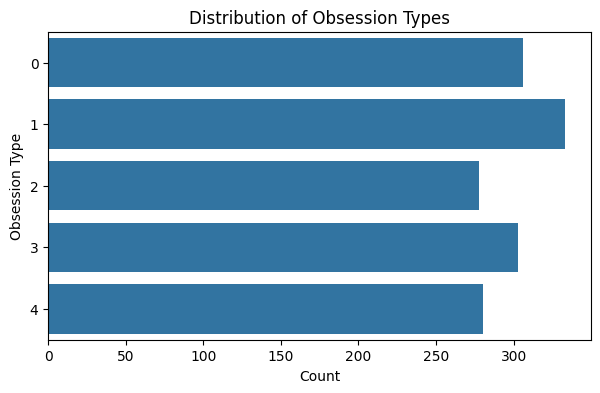

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(y='Obsession Type', data=df)
plt.title("Distribution of Obsession Types")
plt.xlabel("Count")
plt.ylabel("Obsession Type")
plt.show()


Compulsion Type Distribution

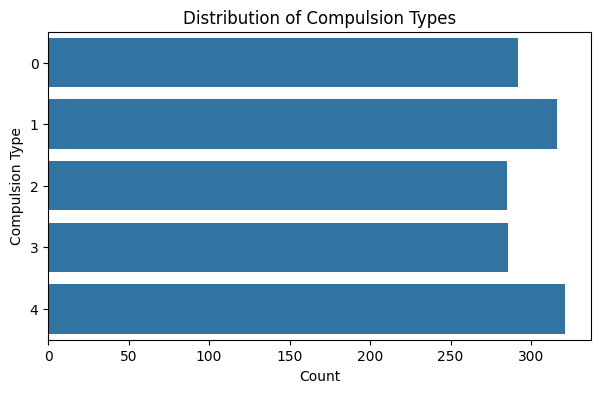

In [ ]:
plt.figure(figsize=(7,4))
sns.countplot(y='Compulsion Type', data=df)
plt.title("Distribution of Compulsion Types")
plt.xlabel("Count")
plt.ylabel("Compulsion Type")
plt.show()


Medication Usage Frequency (Bar Plot)

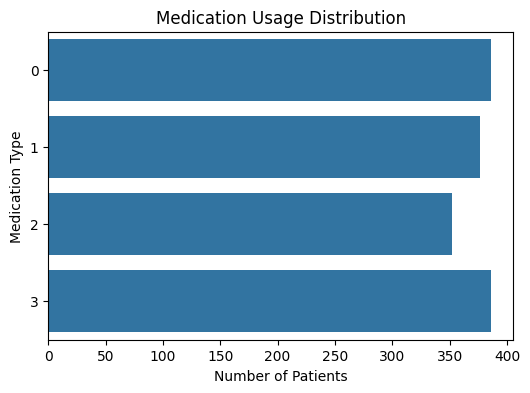

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(y='Medications', data=df)
plt.title("Medication Usage Distribution")
plt.xlabel("Number of Patients")
plt.ylabel("Medication Type")
plt.show()


Depression vs Anxiety Diagnosis Comparison

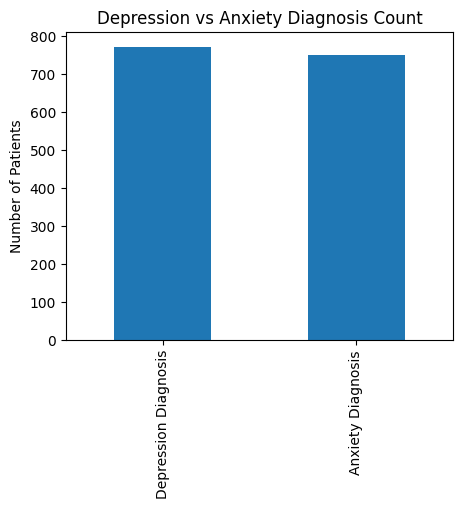

In [ ]:
diagnosis_counts = df[['Depression Diagnosis','Anxiety Diagnosis']].sum()

diagnosis_counts.plot(kind='bar', figsize=(5,4))
plt.title("Depression vs Anxiety Diagnosis Count")
plt.ylabel("Number of Patients")
plt.show()


Y-BOCS Score Distribution (Box Plot)

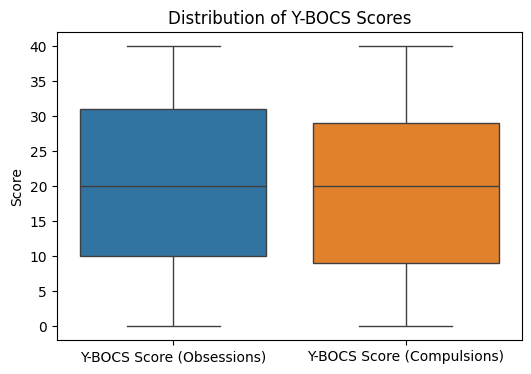

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=df[['Y-BOCS Score (Obsessions)', 'Y-BOCS Score (Compulsions)']])
plt.title("Distribution of Y-BOCS Scores")
plt.ylabel("Score")
plt.show()


Duration of Symptoms by Obsession Type

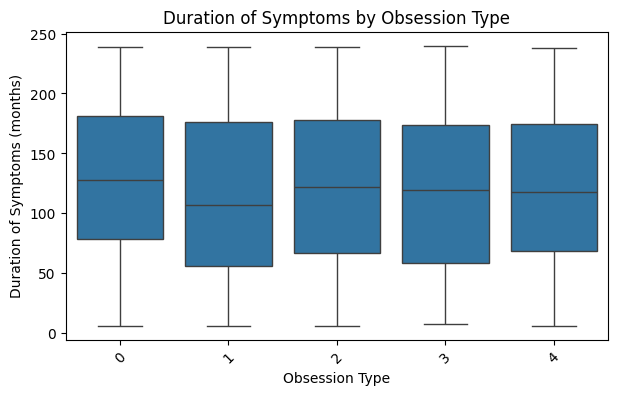

In [ ]:
plt.figure(figsize=(7,4))
sns.boxplot(
    x='Obsession Type',
    y='Duration of Symptoms (months)',
    data=df
)
plt.title("Duration of Symptoms by Obsession Type")
plt.xticks(rotation=45)
plt.show()


Combined Severity Score Plot

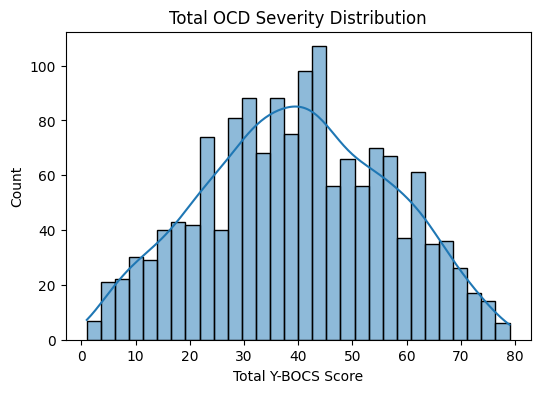

In [ ]:
df['Total Y-BOCS'] = df['Y-BOCS Score (Obsessions)'] + df['Y-BOCS Score (Compulsions)']

plt.figure(figsize=(6,4))
sns.histplot(df['Total Y-BOCS'], bins=30, kde=True)
plt.title("Total OCD Severity Distribution")
plt.xlabel("Total Y-BOCS Score")
plt.show()


Pair Plot (Compact Overview)

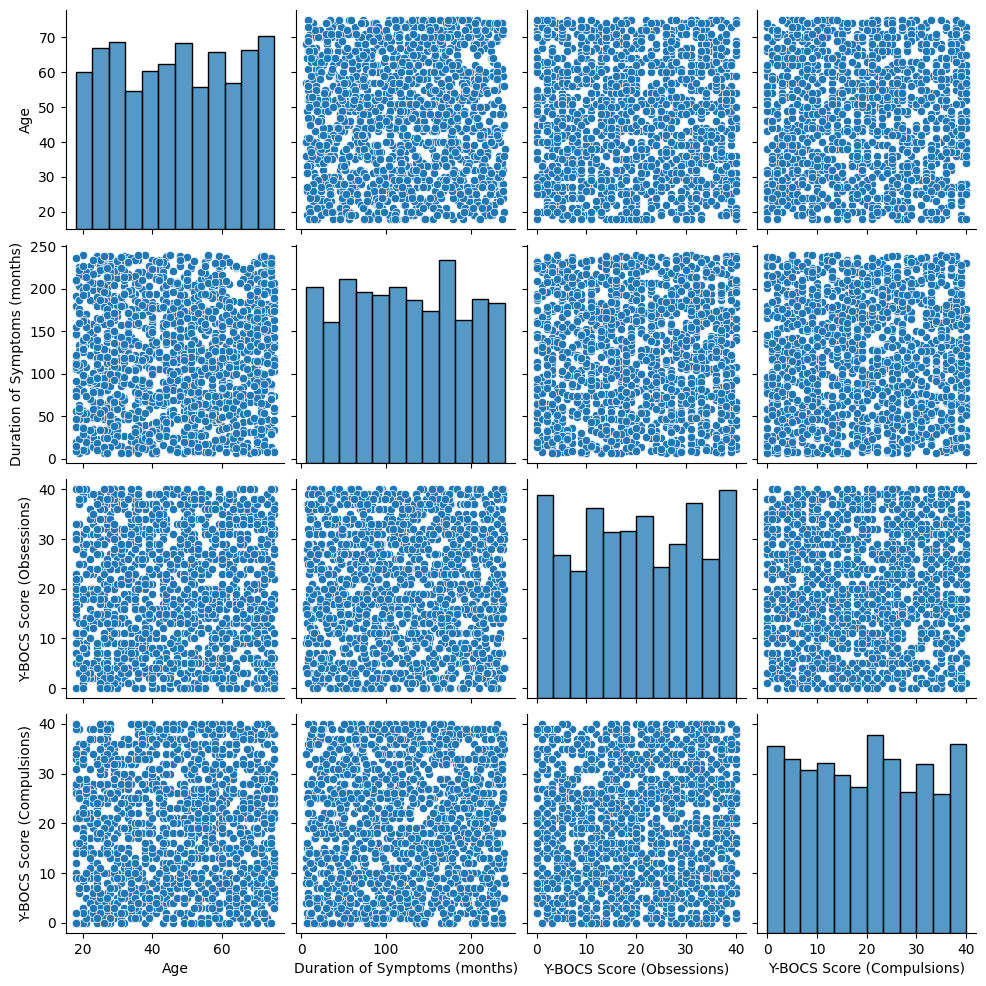

In [ ]:
sns.pairplot(
    df[['Age','Duration of Symptoms (months)',
        'Y-BOCS Score (Obsessions)',
        'Y-BOCS Score (Compulsions)']]
)
plt.show()
